In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from matplotlib.axes import Axes
from matplotlib.cm import coolwarm

import gpflow

2025-09-23 16:22:18.407581: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-23 16:22:18.411251: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-23 16:22:18.579016: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-23 16:22:20.112201: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [19]:
def plot_kernel_samples(ax: Axes, kernel: gpflow.kernels.Kernel) -> None:
    # Create an empty (no data) GP model with the given kernel.
    X = np.zeros((0, 1)) 
    Y = np.zeros((0, 1))
    model = gpflow.models.GPR((X, Y), kernel=deepcopy(kernel))

    # 
    Xplot = np.linspace(-0.6, 0.6, 100)[:, None]
    tf.random.set_seed(20220903)
    n_samples = 3
    
    # predict_f_samples draws n_samples examples of the function f, and returns their values at Xplot.
    fs = model.predict_f_samples(Xplot, n_samples)
    ax.plot(Xplot, fs[:, :, 0].numpy().T, label=kernel.__class__.__name__)
    ax.set_ylim(bottom=-2.0, top=2.0)
    ax.set_title("Example $f$s")


def plot_kernel_prediction(
    ax: Axes, kernel: gpflow.kernels.Kernel, *, optimise: bool = True
) -> None:
    X = np.array([[-0.5], [0.0], [0.4], [0.5]])
    Y = np.array([[1.0], [0.0], [0.6], [0.4]])
    model = gpflow.models.GPR(
        (X, Y), kernel=deepcopy(kernel), noise_variance=1e-3
    )

    if optimise:
        gpflow.set_trainable(model.likelihood, False)
        opt = gpflow.optimizers.Scipy()
        opt.minimize(model.training_loss, model.trainable_variables)

    Xplot = np.linspace(-0.6, 0.6, 100)[:, None]

    f_mean, f_var = model.predict_f(Xplot, full_cov=False)
    f_lower = f_mean - 1.96 * np.sqrt(f_var)
    f_upper = f_mean + 1.96 * np.sqrt(f_var)

    ax.scatter(X, Y, color="black")
    (mean_line,) = ax.plot(Xplot, f_mean, "-", label=kernel.__class__.__name__)
    color = mean_line.get_color()
    ax.plot(Xplot, f_lower, lw=0.1, color=color)
    ax.plot(Xplot, f_upper, lw=0.1, color=color)
    ax.fill_between(
        Xplot[:, 0], f_lower[:, 0], f_upper[:, 0], color=color, alpha=0.1
    )
    ax.set_ylim(bottom=-1.0, top=2.0)
    ax.set_title("Example data fit")


def plot_kernel(
    kernel: gpflow.kernels.Kernel, *, optimise: bool = True
) -> None:
    _, (samples_ax, prediction_ax) = plt.subplots(nrows=1, ncols=2)
    plot_kernel_samples(samples_ax, kernel)
    plot_kernel_prediction(prediction_ax, kernel, optimise=optimise)

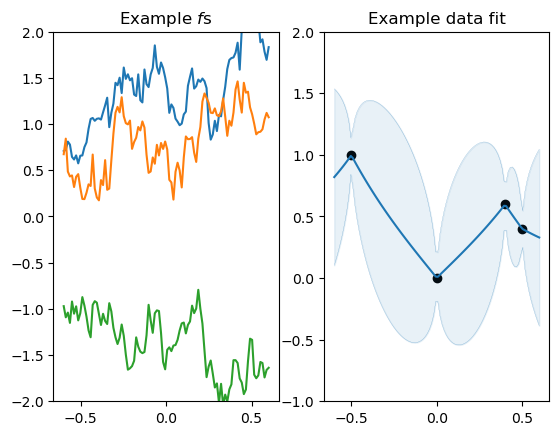

In [20]:
plot_kernel(gpflow.kernels.Matern12())